# Alpha / Beta Anticipatory Power Extraction

Extracts **trial-by-trial anticipatory alpha and beta power** from outcome-locked epochs
for correlation with Rescorla–Wagner (RW) expected values.

### Analysis logic (from poster)
- **Epoch window**: pre-outcome period (action selection → outcome delivery)
- **Alpha (8–13 Hz)**: parieto-occipital ROI (POz, PO3/4, PO7/8, O1/Oz/O2)
- **Beta (13–30 Hz)**: sensorimotor ROI (C3, Cz, C4, CP3/4, FC3/4)
- **Output**: one power scalar per trial → Pearson correlation with RW V(t)

> ⚠️ **Epoch window note**: the pre-outcome window is determined by `EPOCH_TMIN` set in the
> preprocessing notebook. For reliable alpha/beta Hilbert estimation you need ≥ 5 cycles,
> i.e. at least **−0.7 s** for alpha (8 Hz). If your current `EPOCH_TMIN` is only −0.2 s,
> change it in the preprocessing notebook and rerun before using this notebook.

In [2]:
from pathlib import Path
import numpy as np
import mne
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── Parameters ──────────────────────────────────────────────────────────────
SUBJECT = "01"
SESSION = "01"
TASK    = "Cannonball MF"

PROJECT_ROOT    = Path("../..").resolve()
DERIVATIVES_DIR = PROJECT_ROOT / "data" / "derivatives" / "mne_preproc"
sub_ses_dir     = DERIVATIVES_DIR / f"sub-{SUBJECT}" / f"ses-{SESSION}"
prefix          = f"sub-{SUBJECT}_ses-{SESSION}_task-{TASK}"

EPOCHS_PATH = sub_ses_dir / f"{prefix}_epochs_feedback_clean-epo.fif"

# ── Band definitions ─────────────────────────────────────────────────────────
ALPHA_BAND = (8., 13.)
BETA_BAND  = (13., 30.)

# ── Anticipatory window (relative to outcome onset) ──────────────────────────
# Use the pre-outcome baseline period as the expectancy window.
# NOTE: extend EPOCH_TMIN to at least -0.7 s in preprocessing for 5+ alpha cycles.
ANTICI_TMIN = -0.5   # s — 200 ms buffer from epoch start (-0.7 s) for filter settling
ANTICI_TMAX =  0.0   # s

# Edge crop after filtering to reduce Hilbert ringing (one full alpha cycle = 0.125 s)
EDGE_CROP = 0.05     # s trimmed from each side of ANTICI window

# ── ROI channel definitions (standard 10-20 names after biosemi64 montage) ──
# BioSemi64 channels keep their A1-B32 labels in MNE.
# The code below checks which names exist and warns about missing ones.
# Common biosemi64 -> 10-20 equivalents are commented for reference.
ALPHA_ROI_CANDIDATES = [
    "POz", "PO3", "PO4", "PO7", "PO8", "Oz", "O1", "O2",   # standard 10-20 names
    "A17", "A18", "A19", "A20", "B17", "B18", "B19", "B20", # biosemi A/B names fallback
]
BETA_ROI_CANDIDATES = [
    "C3", "Cz", "C4", "CP3", "CP4", "FC3", "FC4",           # standard 10-20 names
    "A10", "A9", "B10", "A12", "B12", "A8", "B8",           # biosemi A/B names fallback
]

# ── Load epochs ──────────────────────────────────────────────────────────────
epochs = mne.read_epochs(str(EPOCHS_PATH), preload=True, verbose=False)

print(f"Loaded  : {len(epochs)} epochs")
print(f"Tmin    : {epochs.tmin:.3f} s    Tmax: {epochs.tmax:.3f} s")
print(f"Channels: {len(epochs.ch_names)}")
print(f"Conditions: {list(epochs.event_id.keys())}")
print(f"\nFirst 10 channel names: {epochs.ch_names[:10]}")

# Clamp anticipatory window to available epoch range
antici_tmin = max(ANTICI_TMIN, epochs.tmin)
antici_tmax = min(ANTICI_TMAX, epochs.tmax)
inner_tmin  = antici_tmin + EDGE_CROP
inner_tmax  = antici_tmax - EDGE_CROP

print(f"\nAnticipatory window  : {antici_tmin:.3f} to {antici_tmax:.3f} s")
if inner_tmin >= inner_tmax:
    print("WARNING: Edge crop leaves no data — skipping crop. Extend EPOCH_TMIN in preprocessing!")
    inner_tmin, inner_tmax = antici_tmin, antici_tmax
else:
    print(f"After edge crop      : {inner_tmin:.3f} to {inner_tmax:.3f} s")

Loaded  : 713 epochs
Tmin    : -0.699 s    Tmax: 0.801 s
Channels: 68
Conditions: ['loss', 'reward']

First 10 channel names: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3']

Anticipatory window  : -0.500 to 0.000 s
After edge crop      : -0.450 to -0.050 s


In [3]:
def pick_roi(epochs, candidates, label):
    """Return channels from candidates that exist in epochs, trying each name."""
    eeg_only = mne.pick_types(epochs.info, eeg=True)
    eeg_names = {epochs.ch_names[i] for i in eeg_only}
    found   = [ch for ch in candidates if ch in eeg_names]
    missing = [ch for ch in candidates if ch not in eeg_names]
    # De-duplicate while preserving order (avoid selecting both A-name and 10-20 name
    # for the same electrode if somehow both exist)
    found = list(dict.fromkeys(found))
    print(f"{label} ROI — using  : {found}")
    if missing:
        print(f"{label} ROI — absent : {missing[:8]}{'...' if len(missing)>8 else ''}")
    assert len(found) > 0, (
        f"No {label} ROI channels found. "
        f"Print epochs.ch_names and update the candidate list above."
    )
    return found

print("Resolving ROIs against available channels...")
alpha_roi = pick_roi(epochs, ALPHA_ROI_CANDIDATES, "Alpha (posterior)")
beta_roi  = pick_roi(epochs, BETA_ROI_CANDIDATES,  "Beta  (sensorimotor)")

Resolving ROIs against available channels...
Alpha (posterior) ROI — using  : ['PO3', 'PO7', 'PO8', 'Oz', 'O1', 'O2']
Alpha (posterior) ROI — absent : ['POz', 'PO4', 'A17', 'A18', 'A19', 'A20', 'B17', 'B18']...
Beta  (sensorimotor) ROI — using  : ['C3', 'Cz', 'C4', 'CP3', 'CP4', 'FC3', 'FC4']
Beta  (sensorimotor) ROI — absent : ['A10', 'A9', 'B10', 'A12', 'B12', 'A8', 'B8']


## Alpha Power (8–13 Hz) — Parieto-Occipital ROI

In [4]:
# 1. Pick ROI channels  2. Bandpass  3. Hilbert envelope  4. Crop  5. Mean power per trial

epochs_alpha_env = (
    epochs
    .copy()
    .pick(alpha_roi)
    .filter(l_freq=ALPHA_BAND[0], h_freq=ALPHA_BAND[1], verbose=False)
    .apply_hilbert(envelope=True)          # instantaneous amplitude (V)
    .crop(tmin=inner_tmin, tmax=inner_tmax)
)

alpha_data  = epochs_alpha_env.get_data()          # (n_trials, n_ch, n_times)
alpha_power = (alpha_data ** 2).mean(axis=(1, 2))  # µV² → mean over channels & time

print(f"Alpha power shape : {alpha_power.shape}  (one scalar per trial)")
print(f"Mean alpha power  : {alpha_power.mean():.4e} V²")
print(f"Std               : {alpha_power.std():.4e} V²")

/var/folders/bg/35xhpjxn5mn8n4n2k4h8pc8w0000gn/T/ipykernel_74021/2556513768.py:7: RuntimeWarning: filter_length (423) is longer than the signal (385), distortion is likely. Reduce filter length or filter a longer signal.
  .filter(l_freq=ALPHA_BAND[0], h_freq=ALPHA_BAND[1], verbose=False)


Alpha power shape : (713,)  (one scalar per trial)
Mean alpha power  : 1.6325e-11 V²
Std               : 1.2151e-11 V²


## Beta Power (13–30 Hz) — Sensorimotor ROI

In [5]:
epochs_beta_env = (
    epochs
    .copy()
    .pick(beta_roi)
    .filter(l_freq=BETA_BAND[0], h_freq=BETA_BAND[1], verbose=False)
    .apply_hilbert(envelope=True)
    .crop(tmin=inner_tmin, tmax=inner_tmax)
)

beta_data  = epochs_beta_env.get_data()
beta_power = (beta_data ** 2).mean(axis=(1, 2))

print(f"Beta power shape : {beta_power.shape}  (one scalar per trial)")
print(f"Mean beta power  : {beta_power.mean():.4e} V²")
print(f"Std              : {beta_power.std():.4e} V²")

Beta power shape : (713,)  (one scalar per trial)
Mean beta power  : 4.4106e-12 V²
Std              : 1.6125e-12 V²


## RW Correlation

Pearson correlation between RW expected value V(t) and anticipatory alpha/beta power.
V(t) comes from the `rw_value` column in the epoch metadata (attached during preprocessing).

Alpha ~ RW V(t) : r = 0.045,  p = 0.2254
Beta  ~ RW V(t) : r = -0.025,  p = 0.4993


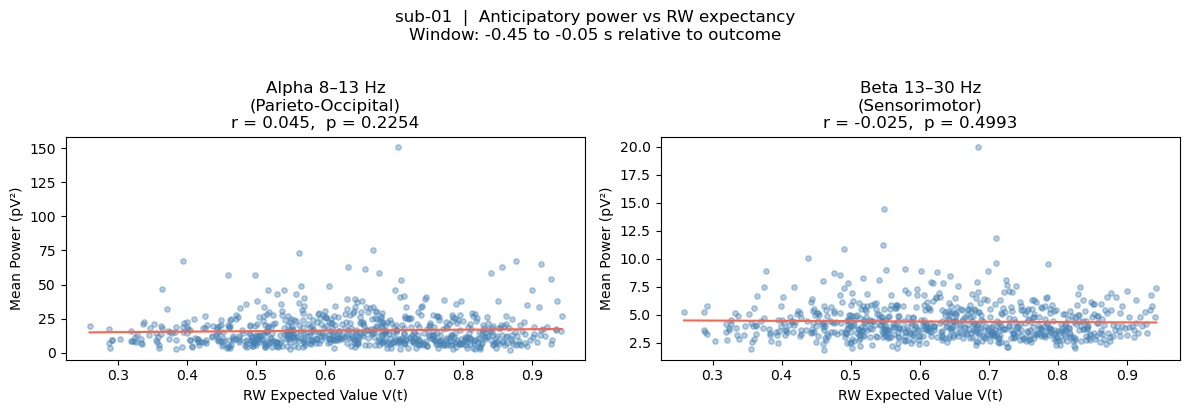

In [6]:
metadata = epochs.metadata

if metadata is None:
    print("No metadata found. Re-run preprocessing with behavioral alignment (cells 41-42).")
elif "rw_value" not in metadata.columns:
    print(f"'rw_value' column not in metadata. Available columns:\n  {list(metadata.columns)}")
    print("Add RW model estimates to the behavioral CSV before preprocessing.")
else:
    rw = metadata["rw_value"].values.astype(float)

    r_alpha, p_alpha = stats.pearsonr(rw, alpha_power)
    r_beta,  p_beta  = stats.pearsonr(rw, beta_power)

    print(f"Alpha ~ RW V(t) : r = {r_alpha:.3f},  p = {p_alpha:.4f}")
    print(f"Beta  ~ RW V(t) : r = {r_beta:.3f},  p = {p_beta:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, pwr, r, p, label in zip(
        axes,
        [alpha_power,         beta_power],
        [r_alpha,             r_beta],
        [p_alpha,             p_beta],
        ["Alpha 8–13 Hz\n(Parieto-Occipital)", "Beta 13–30 Hz\n(Sensorimotor)"],
    ):
        ax.scatter(rw, pwr * 1e12, alpha=0.4, s=15, color="steelblue")  # V² → pV²
        m, b = np.polyfit(rw, pwr * 1e12, 1)
        xline = np.linspace(rw.min(), rw.max(), 100)
        ax.plot(xline, m * xline + b, color="tomato", linewidth=1.5)
        ax.set_xlabel("RW Expected Value V(t)")
        ax.set_ylabel("Mean Power (pV²)")
        ax.set_title(f"{label}\nr = {r:.3f},  p = {p:.4f}")

    fig.suptitle(
        f"sub-{SUBJECT}  |  Anticipatory power vs RW expectancy"
        f"\nWindow: {inner_tmin:.2f} to {inner_tmax:.2f} s relative to outcome",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

rw_value: min=0.259  max=0.943  std=0.152


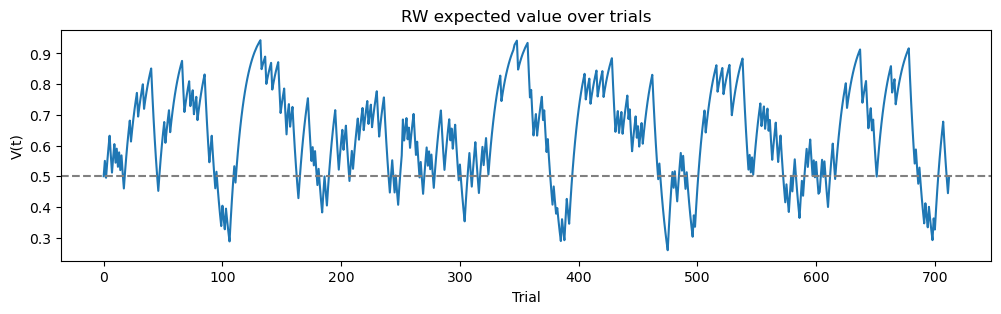

In [7]:
rw = epochs.metadata["rw_value"].values
print(f"rw_value: min={rw.min():.3f}  max={rw.max():.3f}  std={rw.std():.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(12,3))
plt.plot(rw)
plt.axhline(0.5, color='gray', linestyle='--')
plt.xlabel("Trial"); plt.ylabel("V(t)"); plt.title("RW expected value over trials")
plt.show()

## Prediction Error (PE) Correlation

PE = outcome − V(t): the signed surprise on each trial.
Outcome is 1 (reward) or 0 (loss), derived from epoch condition labels.

|PE| stats : min=0.063  max=0.943  std=0.196
Alpha ~ |PE| : r = -0.068,  p = 0.0705
Beta  ~ |PE| : r = 0.006,  p = 0.8658


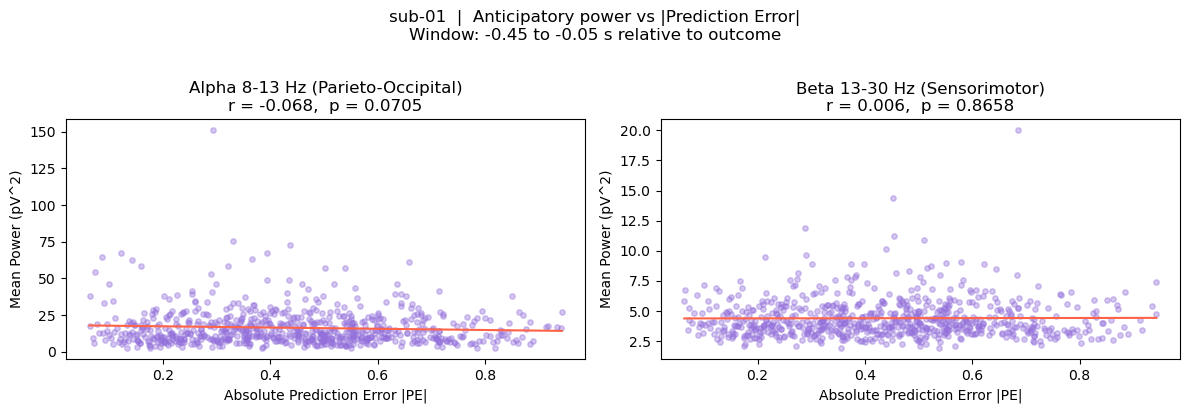

In [8]:
metadata = epochs.metadata

if metadata is None:
    print("No metadata — re-run preprocessing.")
elif "prediction_error" not in metadata.columns:
    print(f"'prediction_error' not in metadata. Available: {list(metadata.columns)}")
    print("Re-run preprocessing Cell 42 to load from trajectories.csv.")
else:
    pe_signed = metadata["prediction_error"].values.astype(float)
    pe = np.abs(pe_signed)  # absolute PE = unsigned surprise magnitude

    r_alpha_pe, p_alpha_pe = stats.pearsonr(pe, alpha_power)
    r_beta_pe,  p_beta_pe  = stats.pearsonr(pe, beta_power)

    print(f"|PE| stats : min={pe.min():.3f}  max={pe.max():.3f}  std={pe.std():.3f}")
    print(f"Alpha ~ |PE| : r = {r_alpha_pe:.3f},  p = {p_alpha_pe:.4f}")
    print(f"Beta  ~ |PE| : r = {r_beta_pe:.3f},  p = {p_beta_pe:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    labels = ["Alpha 8-13 Hz (Parieto-Occipital)", "Beta 13-30 Hz (Sensorimotor)"]
    for ax, pwr, r, p, label in zip(
        axes,
        [alpha_power, beta_power],
        [r_alpha_pe,  r_beta_pe],
        [p_alpha_pe,  p_beta_pe],
        labels,
    ):
        ax.scatter(pe, pwr * 1e12, alpha=0.4, s=15, color="mediumpurple")
        m, b = np.polyfit(pe, pwr * 1e12, 1)
        xline = np.linspace(pe.min(), pe.max(), 100)
        ax.plot(xline, m * xline + b, color="tomato", linewidth=1.5)
        ax.set_xlabel("Absolute Prediction Error |PE|")
        ax.set_ylabel("Mean Power (pV^2)")
        ax.set_title(f"{label}\nr = {r:.3f},  p = {p:.4f}")

    fig.suptitle(
        f"sub-{SUBJECT}  |  Anticipatory power vs |Prediction Error|"
        f"\nWindow: {inner_tmin:.2f} to {inner_tmax:.2f} s relative to outcome",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


## Save Outputs

In [9]:
# 1. Trial-by-trial power arrays (for RW regression / between-subjects averaging)
power_path = sub_ses_dir / f"{prefix}_alpha_beta_power.npz"
np.savez(
    str(power_path),
    alpha_power   = alpha_power,
    beta_power    = beta_power,
    alpha_roi     = np.array(alpha_roi),
    beta_roi      = np.array(beta_roi),
    antici_window = np.array([inner_tmin, inner_tmax]),
    subject       = np.array(SUBJECT),
    session       = np.array(SESSION),
)
print(f"Saved power arrays : {power_path}")

# 2. Full envelope epochs (for time-course inspection / temporal generalisation)
alpha_env_path = sub_ses_dir / f"{prefix}_desc-alpha_env-epo.fif"
epochs_alpha_env.save(str(alpha_env_path), overwrite=True)
print(f"Saved alpha envelope epochs : {alpha_env_path}")

beta_env_path = sub_ses_dir / f"{prefix}_desc-beta_env-epo.fif"
epochs_beta_env.save(str(beta_env_path), overwrite=True)
print(f"Saved beta envelope epochs  : {beta_env_path}")

Saved power arrays : /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_alpha_beta_power.npz
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved alpha envelope epochs : /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_desc-alpha_env-epo.fif
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved beta envelope epochs  : /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_desc-beta_env-epo.fif


In [10]:
# Save per-subject results for between-subjects averaging
results_path = sub_ses_dir / f"sub-{SUBJECT}_ses-{SESSION}_task-{TASK}_results.npz"

save_dict = dict(
    subject      = SUBJECT,
    alpha_power  = alpha_power,
    beta_power   = beta_power,
)

# Add correlation results if they were computed
try:
    save_dict.update(dict(
        r_alpha_V  = r_alpha,   p_alpha_V  = p_alpha,
        r_beta_V   = r_beta,    p_beta_V   = p_beta,
    ))
except NameError:
    print("V(t) correlations not computed — skipping")

try:
    save_dict.update(dict(
        r_alpha_PE = r_alpha_pe, p_alpha_PE = p_alpha_pe,
        r_beta_PE  = r_beta_pe,  p_beta_PE  = p_beta_pe,
    ))
except NameError:
    print("|PE| correlations not computed — skipping")

np.savez(str(results_path), **save_dict)
print(f"Saved results → {results_path}")

Saved results → /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_results.npz
